# Bank Term Deposit Subscription Prediction

Supervised Machine Learning Pipeline

- Dataset: UCI Bank Marketing (4,521 records)
- Task: Binary Classification
- Challenge: Severe class imbalance (~11.5% positive class)


## 1. Library Imports


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading


In [ ]:
df = pd.read_csv("bank.csv", sep=';')

df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,unknown,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,unknown,14,may,57,2,-1,0,unknown,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


Define column types

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical columns:", num_cols)

Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [ ]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", cat_cols)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


##2.2 Target Variable

- Class Imbalance: The target variable is highly imbalanced:

- 88.48% of individuals did not subscribe to the term deposit ("no").

- 11.52% of individuals subscribed ("yes").

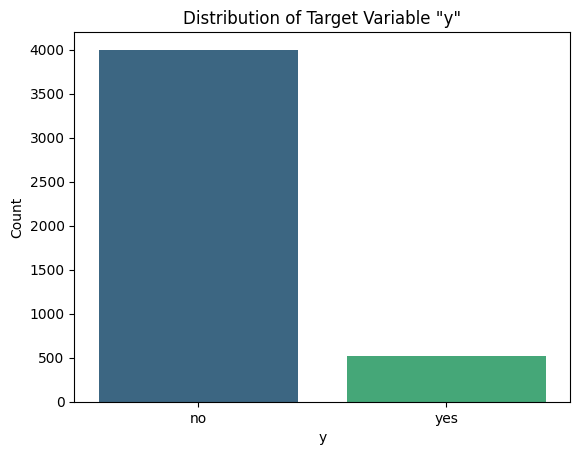

,y,Percentage
0,no,88.476001
1,yes,11.523999


In [ ]:
sns.countplot(x='y', data=df, hue='y', palette='viridis', legend=False)
plt.title('Distribution of Target Variable "y"')
plt.xlabel('y')
plt.ylabel('Count')
plt.show()

# Calculate the distribution of the target variable 'y' in percentages
target_distribution = df['y'].value_counts(normalize=True) * 100

# Convert to a DataFrame for better display
target_distribution = target_distribution.reset_index()
target_distribution.columns = ['y', 'Percentage']

# Display the distribution
display(target_distribution)

## 2.3 Demographic Variables and Subscription Behaviour

- Age: The distribution is right-skewed, with clients aged 30–45 showing the highest subscription rates.

- Job: Admin, blue-collar, and technician roles dominate the dataset, but retired clients show the highest conversion rates.

- Marital Status: Single clients have higher subscription rates than married or divorced clients, possibly due to fewer financial obligations.

- Education: Clients with tertiary education subscribe the most, whereas those with only primary education have the lowest uptake.

- Account Balance: Right-skewed with high-value outliers; clients above the upper quartile are more likely to subscribe, suggesting liquidity is a strong predictor.

- Housing and Personal Loans: Clients without existing loans show higher subscription rates compared to those with loans.

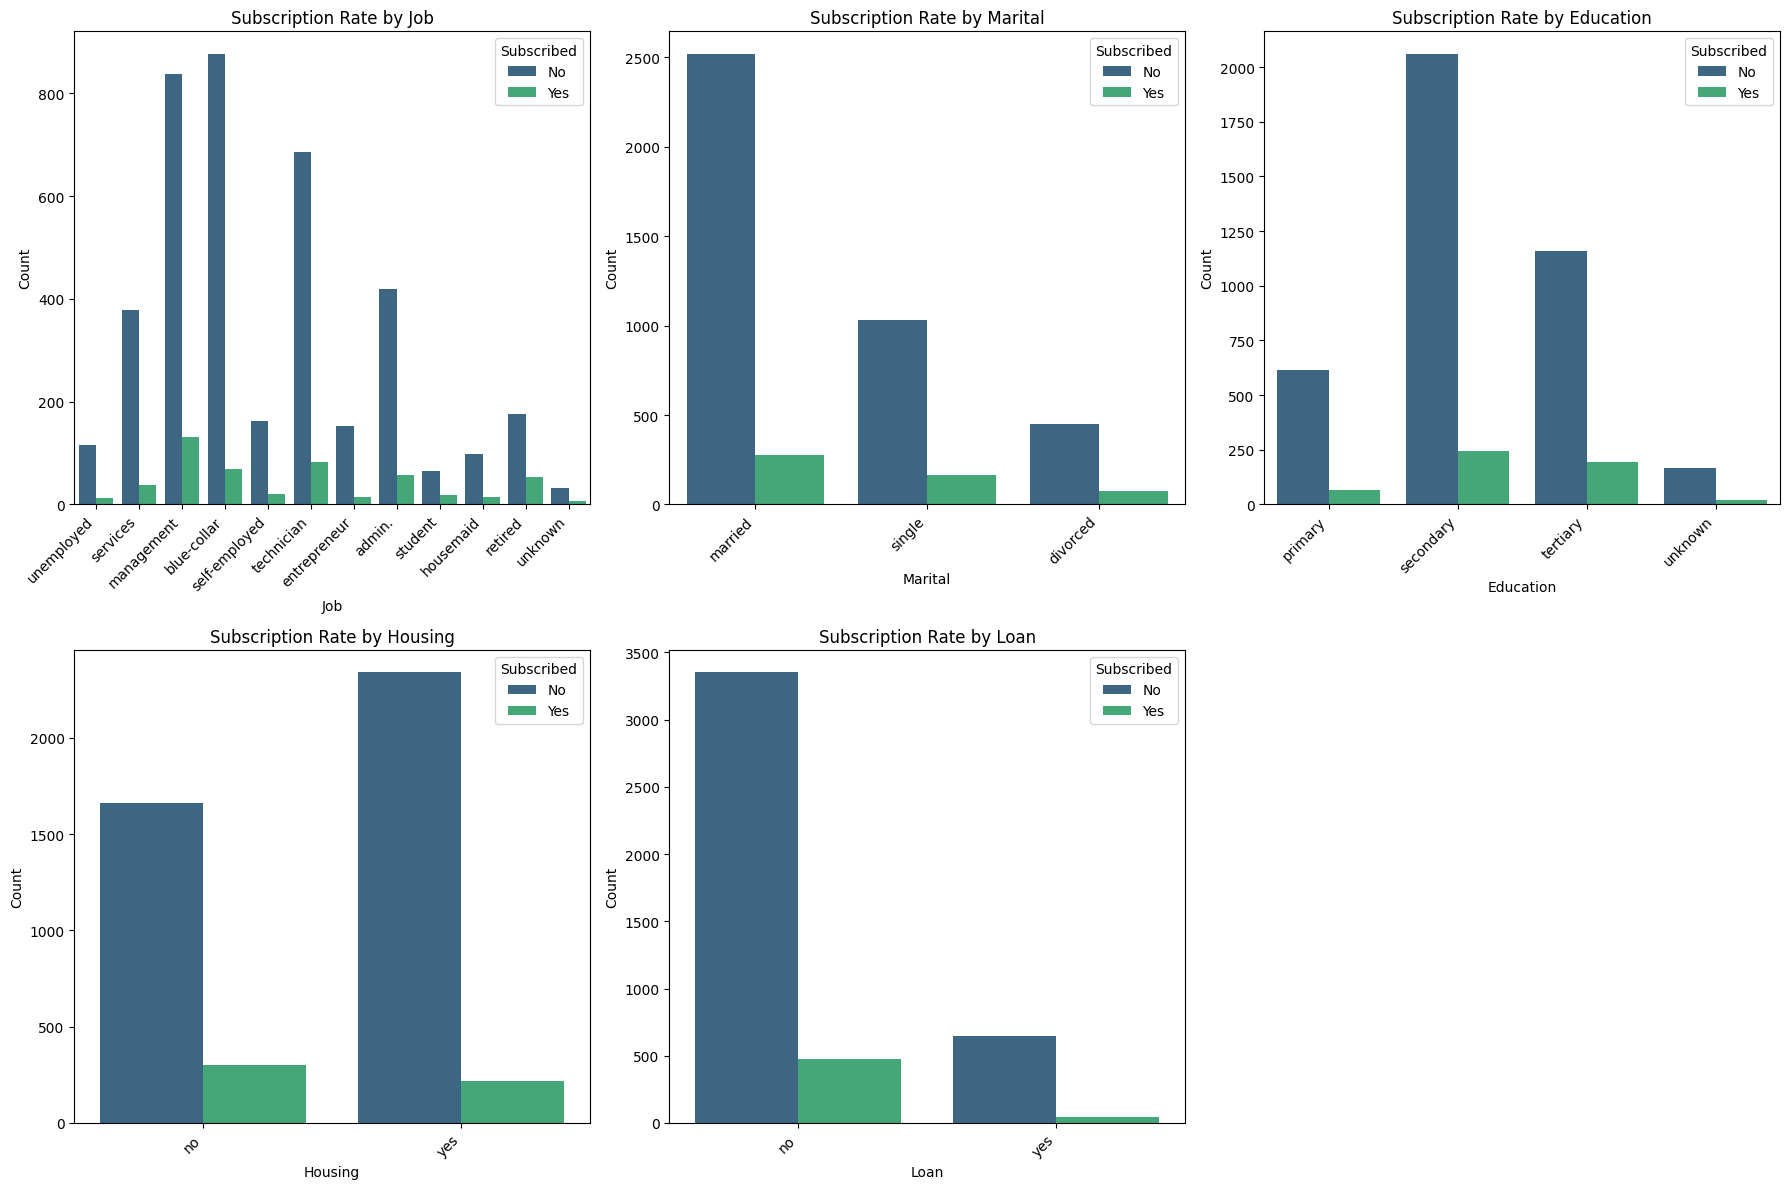

In [ ]:
# Categorical Box plots

plt.figure(figsize=(18, 12))

categorical_features_for_bar = ['job', 'marital', 'education', 'housing', 'loan']

for i, feature in enumerate(categorical_features_for_bar, 1):
    plt.subplot(2, 3, i) # Adjust subplot grid as needed, e.g., 2 rows, 3 columns
    sns.countplot(data=df, x=feature, hue='y', palette='viridis')
    plt.title(f'Subscription Rate by {feature.capitalize()}')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
    plt.legend(title='Subscribed', labels=['No', 'Yes'])

# 6. Adjust the layout of the plots and display
plt.tight_layout()
plt.show()

## 2.4 Numerical Feature Analysis and Correlations
Duration (0.40): Shows the strongest positive correlation with subscription. Longer call durations are associated with a higher likelihood of clients subscribing, reflecting deeper engagement and stronger conversion potential.

Pdays & Previous (0.58): Moderate correlation between these two features. Clients who were contacted recently and have had multiple prior interactions are more likely to subscribe.

Other Variables (Age, Balance, Day, Campaign): These show weak correlations with the target, indicating limited influence on subscription outcomes.


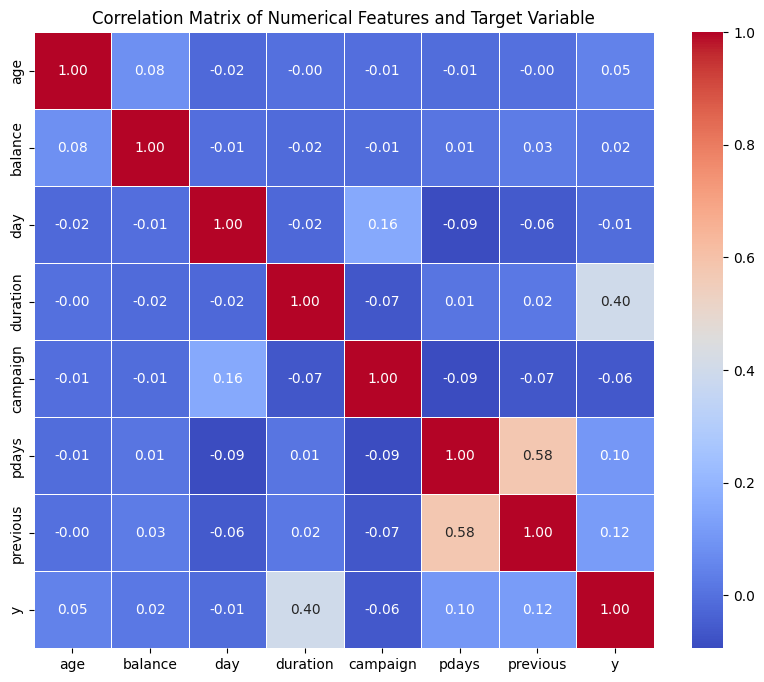

In [ ]:
df_encoded = df.copy()
df_encoded['y'] = df_encoded['y'].map({'yes': 1, 'no': 0})

numerical_cols_with_target = num_cols + ['y']
correlation_matrix = df_encoded[numerical_cols_with_target].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features and Target Variable')
plt.show()

## 2.5 Call Duration Analysis  

Subscribers: Tend to have longer calls, with a higher median and wider interquartile range (IQR), indicating stronger engagement.

Non-subscribers: Typically have shorter calls, with more concentrated durations, suggesting lower interest.

Outliers: Calls longer than 1000 seconds appear in both groups, but are more frequent among subscribers, implying that longer conversations may drive conversions.

Predictive Value: Call duration shows a moderate positive correlation (0.40) with subscription likelihood.

Distribution: Right-skewed with extreme outliers, log transformation or tree-based models are recommended for better modeling.

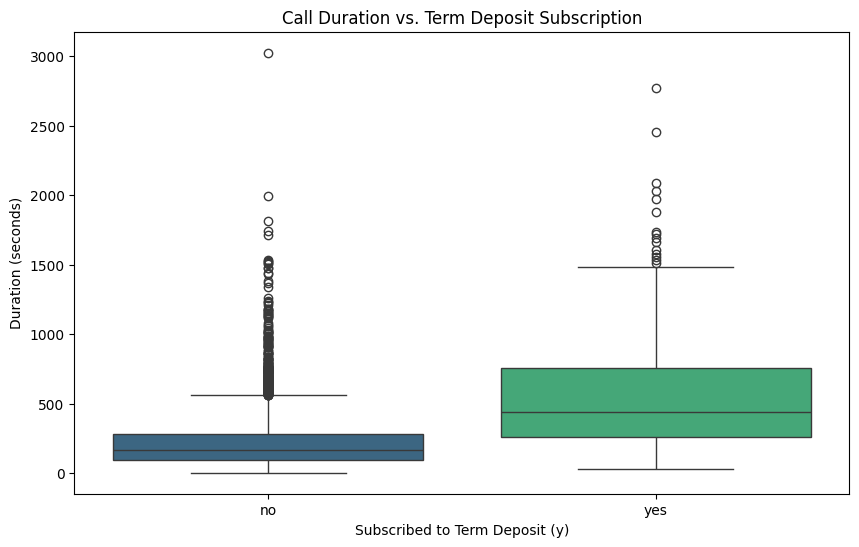

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='y', y='duration', data=df, hue='y', palette='viridis', legend=False)
plt.title('Call Duration vs. Term Deposit Subscription')
plt.xlabel('Subscribed to Term Deposit (y)')
plt.ylabel('Duration (seconds)')
plt.show()

## 5. Train-Test Split


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import RocCurveDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt


## 3. Data Exploration


In [ ]:
df = pd.read_csv('/content/bank.csv', sep=';', quotechar='"')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


This allows us to check that the data was imported properly and confirms that each column contains the expected values. For example, we can see how job, education and the subscription outcomes are represented in the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


From the output we can see that the dataset contains 4521 rows and 17 columns, and all columns have 4521 non-null entries, meaning there are no missing values. It shows the numerical features (int64) and the categorical features (object). This helps guide preprocessing decisions such as scaling numerical data and one-hot encoding categorical data.

In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

We can see from the output that this dataset contains a mix of numerical and categorical attributes such as age, job, marital, balance, and target variable y. This step is important because it allows us to understand the structure of the data before applying further preprocessing.

Data Cleaning

In [ ]:
cols = df.columns
new_cols = []

for column in cols:
    proper_col = column.title()
    clean_col = proper_col.replace("-", "_")
    new_cols.append(clean_col)

df.columns = new_cols

df.head()

,Age,Job,Marital,Education,Default,Balance,Housing,Loan,Contact,Day,Month,Duration,Campaign,Pdays,Previous,Poutcome,Y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


This step makes the dataset cleaner and more consistent, this helps avoid errors later during modelling. After this,  df.head() shows the first few rows with the updated tidy labels from Age to Poutcome.

Data Types

In [ ]:
df.dtypes

,0
Age,int64
Job,object
Marital,object
Education,object
Default,object
Balance,int64
Housing,object
Loan,object
Contact,object
Day,int64


The output reveals that the dataset contains a mix of int64 numerical features (Age, Balance, Duration, Campaign, Pdays and Previous) and object-type categorical features (Job, Marital, Education and Y). Understanding the data types is important because numerical features need scaling, while categorical features need encoding before they can be used in machine learning models.

Missing data

In [ ]:
df_cleaned = df.dropna()

The df_cleaned will be identical to the original df. However, this step is included as a precaution for any modification or expansion to the dataset in the future.

In [ ]:
df.isnull().sum()

,0
Age,0
Job,0
Marital,0
Education,0
Default,0
Balance,0
Housing,0
Loan,0
Contact,0
Day,0


The output that all columns have a value of 0, meaning there are no missing entries in the dataset. This is useful as it confirms that we do not need to fill or remove any missing data before training the model. Since there are no null values, we can move straight into preprocessing tasks scaling and encoding.

In [ ]:
missing_pct = round(df.isnull().sum()/len(df)* 100,1)
print(missing_pct)

Age          0.0
Job          0.0
Marital      0.0
Education    0.0
Default      0.0
Balance      0.0
Housing      0.0
Loan         0.0
Contact      0.0
Day          0.0
Month        0.0
Duration     0.0
Campaign     0.0
Pdays        0.0
Previous     0.0
Poutcome     0.0
Y            0.0
dtype: float64


The output shows that every column contains 0% missing data. Once again confirming there are no null entries in the dataset and allowing us to proceed with the next preprocessing steps.

Skewness

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
numeric_cols.skew()

,0
Age,0.699501
Balance,6.596431
Day,0.094627
Duration,2.772420
Campaign,4.743914
Pdays,2.717071
Previous,5.875259


The output shows that several features, such as Balance, Campaign and Previous, have high skewness values, meaning their distributions are not symmetrical. Most values are clustered toward the lower end, while a small number of extreme values stretch the distribution to the right. Highly skewed data can affect model performance, especially for algorithms that assume data is normally distributed, because outliers and uneven distributions can influence how the model learns patterns. However, in this dataset, high skewness is expected because most customers have low balances or few previous contacts, while only a small number show unusually high values.

In [ ]:
print("Mean:", df['Age'].mean())
print("Median:", df['Age'].median())
print("Mode:", df['Age'].mode()[0])

Mean: 41.17009511170095
Median: 39.0
Mode: 34


The mean is around 41, the median is 39 and the mode is 34. Since the mean is slightly higher than the median, this supports the finding of a positive skew because there are fewer larger Age values pulling the mean upward. This helps us understand the typical customer age and whether the distribution is symmetrical or influenced by older people.

In [ ]:
print("Skewness:", df['Age'].skew)
print("Outliers:", df['Age'].quantile(0.99))

Skewness: <bound method Series.skew of 0       30
1       33
2       35
3       30
4       59
        ..
4516    33
4517    57
4518    57
4519    28
4520    44
Name: Age, Length: 4521, dtype: int64>
Outliers: 72.0


 The 99th percentile value of 72 suggests that ages above this may be considered outliers. This helps us understand whether the data is balanced or if extreme values will influence the model.

In [ ]:
median_units = df['Age'].median()
df['Age']=df['Age'].fillna(median_units)


Even though, this dataset has no missing values, this step is included again for precaution in case any missing values appear later. The median was used as it is not influenced by outliers and keeps distribution of ages realistic.  

In [ ]:
df['Age'].isnull().sum()

np.int64(0)

This helps confirm the Age data is complete and does not require any further cleaning before moving onto the next preprocessing step.

Data Scaling

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [ ]:
bank_df = pd.read_csv("bank.csv", sep=';')

The  sep= ‘;’ argument is used as the file separates values with semicolons instead of commas. This ensures data is read correctly and each column is properly identified.

In [ ]:
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

scaler = StandardScaler()
bank_df[num_cols] = scaler.fit_transform(bank_df[num_cols])

bank_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,-1.056270,unemployed,married,primary,no,0.121072,no,no,cellular,19,oct,-0.711861,-0.576829,-0.407218,-0.320413,unknown,no
1,-0.772583,services,married,secondary,no,1.118644,yes,yes,cellular,11,may,-0.169194,-0.576829,2.989044,2.041734,failure,no
2,-0.583458,management,single,tertiary,no,-0.024144,yes,no,cellular,16,apr,-0.303898,-0.576829,2.899143,0.270124,failure,no
3,-1.056270,management,married,tertiary,no,0.017726,yes,yes,unknown,3,jun,-0.250017,0.387967,-0.407218,-0.320413,unknown,no
4,1.686036,blue-collar,married,secondary,no,-0.472753,yes,no,unknown,5,may,-0.146102,-0.576829,-0.407218,-0.320413,unknown,no


 Scaling makes numerical features easier for machine learning algorithms to learn from, especially models like Logistic Regression because it puts all values on a similar range, preventing large-scale features from dominating the model. After scaling, the values appear as standardised numbers instead of their original ranges this helps improve model performance.

One Hot Encoding

## 4. Preprocessing Pipeline


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [ ]:
categorical_columns = ['Job', 'Marital', 'Education', 'Default', 'Housing', 'Loan', 'Contact', 'Month', 'Poutcome']

numeric_columns = ['Age','Balance','Day','Duration','Campaign','Pdays','Previous']


Categorical columns contain text labels such as Job or Marital, while numerical columns contain number values such as Age and Balance. Splitting the data allows us to apply the correct preprocessing techniques to each type.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_columns),
        ('num', StandardScaler(), numeric_columns)
    ]
)


Using drop='first' prevents a high correlation between encoded features by avoiding duplicate information. The ColumnTransformer ensures all preprocessing steps are applied consistently and correctly before modelling.

# **4.1 Data Splitting**

The Train test split technique in machine learning divides a dataset into two sections, training and testing sets. This is used to evaluate how well a model generalises new data. If a model is testing using the same data and not use the train test split, it does not simulate how a model would perform on new data. It also tends to reward complex models that overfit (when a ML model performs well with the training data but poorly with new data) on the data, meaning it doesn’t generalise and attempts to fit the new data too closely to the training data. (Galarnyk, 2022). Additionally, data leakage occurs when a model uses information during training that would not be available at the time of prediction. Whilst being trained on the predictive model, it will look accurate, however until it is deployed in its use case then it will yield inaccurate results (IBM, 2024a).

## 6. Logistic Regression Model


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [ ]:
X = df.drop("Y", axis=1)
y = df["Y"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

The 80/20 split was used to create a large enough training set for the model to learn patterns instead of memorising the data, while 20% is an appropriate amount for the test set to give a reliable evaluation of the model’s performance.

# **4.2 Model Training**

# 4.2.1 Logistic Regression

In [ ]:
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('logreg', LogisticRegression(max_iter=10000))
])


In [ ]:
model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Job', 'Marital',
                                                   'Education', 'Default',
                                                   'Housing', 'Loan', 'Contact',
                                                   'Month', 'Poutcome']),
                                                 ('num', StandardScaler(),
                                                  ['Age', 'Balance', 'Day',
                                                   'Duration', 'Campaign',
                                                   'Pdays', 'Previous'])])),
                ('logreg', LogisticRegression(max_iter=10000))])

The code uses Pipeline which allows for several steps to be assembled, while setting different parameters (scikit-learn.org, n.d.). The Pipeline has two steps, the first is the preprocessor object that handles missing data, encodes categorical features and other transformational techniques. Even though the dataset has previously been cleaned and scaled manually, the preprocessor ensures every transformation is used and protects against the risk of data leakage.  

The Logistic Regression is the Machine Learning (ML) model chosen; the max_iter is the “maximum number of iterations taken for the solvers to converge” (scikit-learn, 2014). 1000 iterations were used to allow the model plenty of time to find a good solution.  

Lastly, .fit() is used to run the preprocessing on X_train, then trains the Logistic Regression model on the processed data. This learns the relationships between the input features and the target labels (y_train).

# 4.2.2 Random Forest

## 7. Random Forest Model


In [ ]:
from sklearn.ensemble import RandomForestClassifier


rf_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Job', 'Marital',
                                                   'Education', 'Default',
                                                   'Housing', 'Loan', 'Contact',
                                                   'Month', 'Poutcome']),
                                                 ('num', StandardScaler(),
                                                  ['Age', 'Balance', 'Day',
                                                   'Duration', 'Campaign',
                                                   'Pdays', 'Previous'])])),
                ('rf',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

The Random Forest was additionally used to compare techniques. The Pipeline is used the same as the Logistic Regression, to group together all steps and make the code cleaner.  

The n_estimators was increased to 200 decision trees as this means an increase in accuracy and reduce variance which can improve generalisation.   

The random_state ensures that results are reproducible, which is important for debugging or sharing the model with others (GeeksforGeeks, 2024)7.

When .fit() is called, it runs the data through the preprocess step, then feeds the data into the Random Forest. The model builds 200 decision trees, learns the patterns in the training set and prepares to classify new examples.  

# **4.3 Initial Results**

# 4.3.1 Logisitic Regression CR + CM

Logistic Regression - Classification Report:

              precision    recall  f1-score   support

          no       0.91      0.97      0.94       801
         yes       0.56      0.30      0.39       104

    accuracy                           0.89       905
   macro avg       0.74      0.63      0.67       905
weighted avg       0.87      0.89      0.88       905



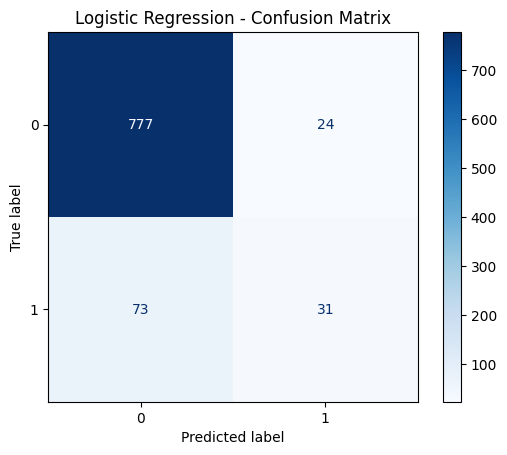

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


y_pred_logreg = model.predict(X_test)

print("Logistic Regression - Classification Report:\n")
print(classification_report(y_test, y_pred_logreg))

cm_logreg = confusion_matrix(y_test, y_pred_logreg)
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg)
disp_logreg.plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()



## 9. Model Evaluation (ROC & AUC)


Logistic Regression AUC: 0.8918419283587822


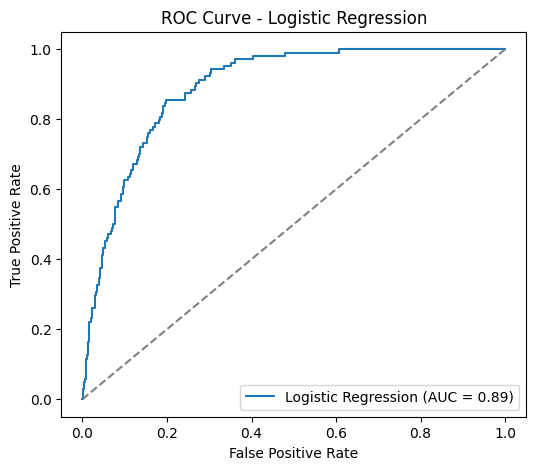

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_logreg = model.predict_proba(X_test)[:, 1]

fpr_logreg, tpr_logreg, thresholds_logreg = roc_curve(y_test, y_prob_logreg, pos_label='yes')

auc_logreg = roc_auc_score(y_test, y_prob_logreg)
print("Logistic Regression AUC:", auc_logreg)

plt.figure(figsize=(6, 5))
plt.plot(fpr_logreg, tpr_logreg, label=f"Logistic Regression (AUC = {auc_logreg:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()



# 4.3.2 Random Forest - CR + CM

Random Forest - Classification Report:

              precision    recall  f1-score   support

          no       0.91      0.97      0.94       801
         yes       0.52      0.24      0.33       104

    accuracy                           0.89       905
   macro avg       0.71      0.61      0.63       905
weighted avg       0.86      0.89      0.87       905



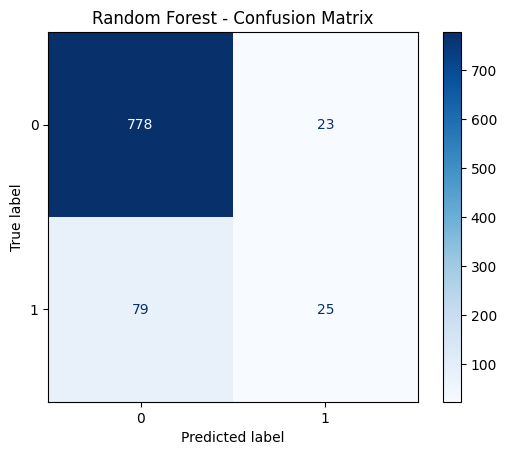

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_rf = rf_model.predict(X_test)

print("Random Forest - Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.show()


Random Forest AUC: 0.9025076827043119


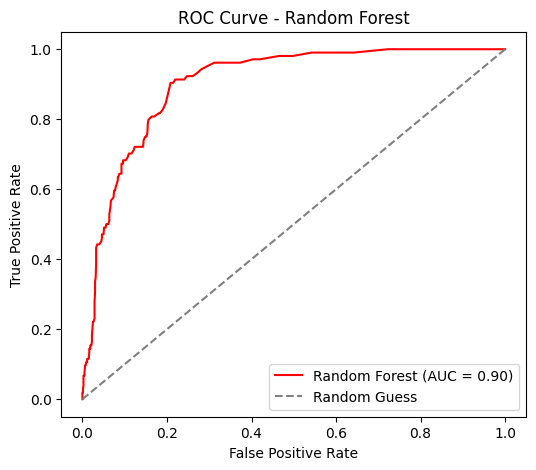

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf, pos_label='yes')

auc_rf = roc_auc_score(y_test, y_prob_rf)
print("Random Forest AUC:", auc_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})", color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()



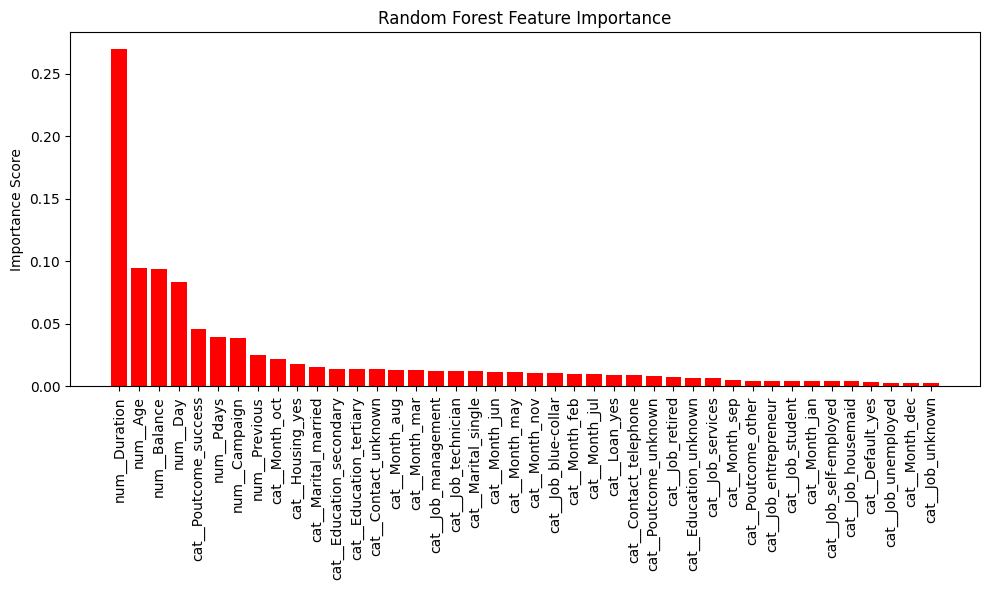

In [ ]:
# Get feature names after preprocessing
feature_names = rf_model.named_steps['preprocess'].get_feature_names_out()

# Access feature importances
importances = rf_model.named_steps['rf'].feature_importances_
indices = np.argsort(importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importance")
plt.bar(range(len(importances)), importances[indices], align="center", color="red")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

# **5.2 - Model Improvements (Hyperparameter Tuning)**

# 5.2.1 Logisitic Regression Tuning

## 8. Hyperparameter Tuning


In [ ]:
from sklearn.model_selection import GridSearchCV

logreg_param_grid = {
    "logreg__C": [0.001, 0.01, 0.1, 1, 10]
}

logreg_grid = GridSearchCV(
    estimator=model,
    param_grid=logreg_param_grid,
    cv=5,
    scoring="f1_macro"
)

logreg_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:", logreg_grid.best_params_)


Best Logistic Regression Parameters: {'logreg__C': 10}


# 5.2.2 Random Forest Tuning

In [ ]:
rf_param_grid = {
    "rf__n_estimators": [100, 150],
    "rf__max_depth": [None, 10],
    "rf__min_samples_split": [2, 5]
}


rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)



Best Random Forest Parameters: {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}


# **5.3 - Improved Results**

# 5.3.1 Logistic Regression - After Tuning

Tuned Logistic Regression - Classification Report:

              precision    recall  f1-score   support

          no       0.91      0.97      0.94       801
         yes       0.54      0.30      0.39       104

    accuracy                           0.89       905
   macro avg       0.73      0.63      0.66       905
weighted avg       0.87      0.89      0.88       905



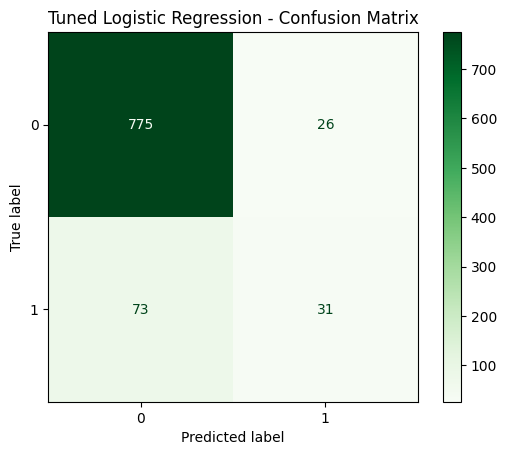

In [ ]:
best_logreg = logreg_grid.best_estimator_
y_pred_logreg_tuned = best_logreg.predict(X_test)

print("Tuned Logistic Regression - Classification Report:\n")
print(classification_report(y_test, y_pred_logreg_tuned))

cm_logreg_tuned = confusion_matrix(y_test, y_pred_logreg_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logreg_tuned)
disp.plot(cmap='Greens')
plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.show()


# 5.3.2 Random Forest — Improved Evaluation

Tuned Random Forest - Classification Report:

              precision    recall  f1-score   support

          no       0.91      0.98      0.94       801
         yes       0.57      0.25      0.35       104

    accuracy                           0.89       905
   macro avg       0.74      0.61      0.64       905
weighted avg       0.87      0.89      0.87       905



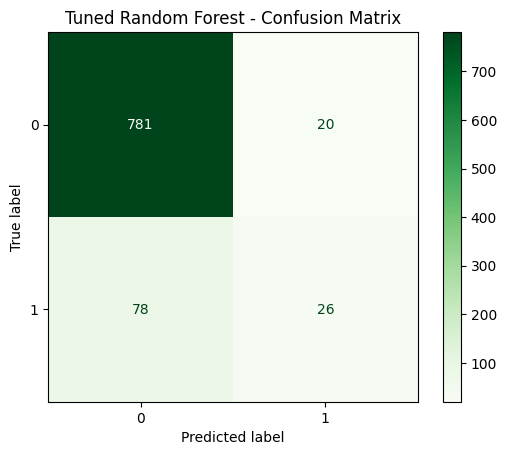

In [ ]:
best_rf = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

print("Tuned Random Forest - Classification Report:\n")
print(classification_report(y_test, y_pred_rf_tuned))

cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_tuned)
disp.plot(cmap='Greens')
plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()


# 5.3.3 Comparison Table — Before vs After Tuning

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression (Before)", "Logistic Regression (After)",
              "Random Forest (Before)", "Random Forest (After)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_logreg_tuned),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_tuned)
    ]
})

print(comparison_df)


                          Model  Accuracy
0  Logistic Regression (Before)  0.892818
1   Logistic Regression (After)  0.890608
2        Random Forest (Before)  0.887293
3         Random Forest (After)  0.891713
